In [5]:
import numpy as np
import scipy.io.wavfile as wav
import matplotlib.pyplot as plt


In [3]:
def simulate_microphone_array(audio_file, source_pos, chunk_start_sec, chunk_end_sec):
    # 1. Load the source audio
    # fs is the sampling frequency (e.g., 44100 or 16000)
    fs, source_audio = wav.read(audio_file)

    # Convert to mono if it's stereo by taking the first channel
    if len(source_audio.shape) > 1:
        source_audio = source_audio[:, 0]

    # Normalize audio to -1.0 to 1.0 (assuming 16-bit PCM WAV)
    source_audio = source_audio.astype(np.float32) / np.iinfo(np.int16).max

    # 2. Define the 3D Coordinates (in meters)
    # A standard tetrahedral array with roughly 10cm spacing.
    # Mic 1 is the reference at the origin (0, 0, 0).
    mic_positions = np.array([
    [0.0, 0.0, 0.0],          # Mic 1 (Reference)
    [0.1, 0.0, 0.0],          # Mic 2 (10cm on X axis)
    [0.05, 0.0866, 0.0],      # Mic 3 (Equilateral triangle on XY plane)
    [0.05, 0.0289, 0.0816]    # Mic 4 (Elevated on Z axis)
    ])

    # 3. Calculate Distances and Delays
    SPEED_OF_SOUND = 343.0 # m/s

    mic_signals = []
    for idx, mic_pos in enumerate(mic_positions):
        # Euclidean distance from source to this microphone
        distance = np.linalg.norm(source_pos - mic_pos)

        # Time of arrival in seconds
        time_delay = distance / SPEED_OF_SOUND

        # Convert time delay to discrete samples
        sample_delay = int(np.round(time_delay * fs))

        print(f"Mic {idx+1}: Distance = {distance:.3f}m, Delay = {sample_delay} samples")

        # 4. Shift the audio by padding with zeros at the beginning
        # This simulates the time it takes for sound to reach the mic from t=0
        delayed_audio = np.pad(source_audio, (sample_delay, 0), mode='constant')
        mic_signals.append(delayed_audio)

    # Make all arrays the same length (pad the ends to match the longest signal)
    max_len = max(len(sig) for sig in mic_signals)
    for i in range(len(mic_signals)):
        mic_signals[i] = np.pad(mic_signals[i], (0, max_len - len(mic_signals[i])), mode='constant')

    # Convert list of arrays to a 2D numpy matrix (4 rows x N samples)
    mic_matrix = np.array(mic_signals)

    # 5. Extract the requested middle chunk
    start_sample = int(chunk_start_sec * fs)
    end_sample = int(chunk_end_sec * fs)

    # Ensure we don't slice past the end of the audio
    end_sample = min(end_sample, mic_matrix.shape[1])

    chunked_signals = mic_matrix[:, start_sample:end_sample]

    return fs, chunked_signals





In [20]:
# --- Example Usage ---
# Source at x=2.0m, y=1.5m, z=0.5m
source_coordinate = np.array([-2.0, -1.5, -0.5]) 

    # Extract from t=1.0s to t=3.0s
sample_rate, final_audio_matrix = simulate_microphone_array(
    "source.wav", 
    source_coordinate, 
    chunk_start_sec=1.0, 
    chunk_end_sec=3.0
)

print(f"\nFinal matrix shape: {final_audio_matrix.shape} (4 mics, N samples)")

Mic 1: Distance = 2.550m, Delay = 178 samples
Mic 2: Distance = 2.629m, Delay = 184 samples
Mic 3: Distance = 2.640m, Delay = 185 samples
Mic 4: Distance = 2.623m, Delay = 184 samples

Final matrix shape: (4, 48000) (4 mics, N samples)


In [ ]:
def run_nlms(x, d, L, mu=0.1):
    """
    Normalized LMS (NLMS) is used here instead of standard LMS 
    because it automatically adjusts to the audio signal's power, 
    preventing the math from diverging/exploding.
    """
    N = len(x)
    w = np.zeros(L)  # Initialize filter weights to zero
    
    
    for n in range(L, N):
        # Extract the sliding window of L samples from the input
        x_vec = x[n : n-L : -1] 
        
        # 1. Filter Phase (Dot Product)
        y = np.dot(w, x_vec)
        
        # 2. Error Calculation
        e = d[n] - y
        
        # 3. Weight Update Phase (NLMS variant)
        power = np.dot(x_vec, x_vec)
        w = w + mu * e * x_vec
        
    return w



Running LMS Filters...

Calculated Delays relative to Mic 1:
Mic 2 Delay (tau_21): 27 samples
Mic 3 Delay (tau_31): 26 samples
Mic 4 Delay (tau_41): 27 samples


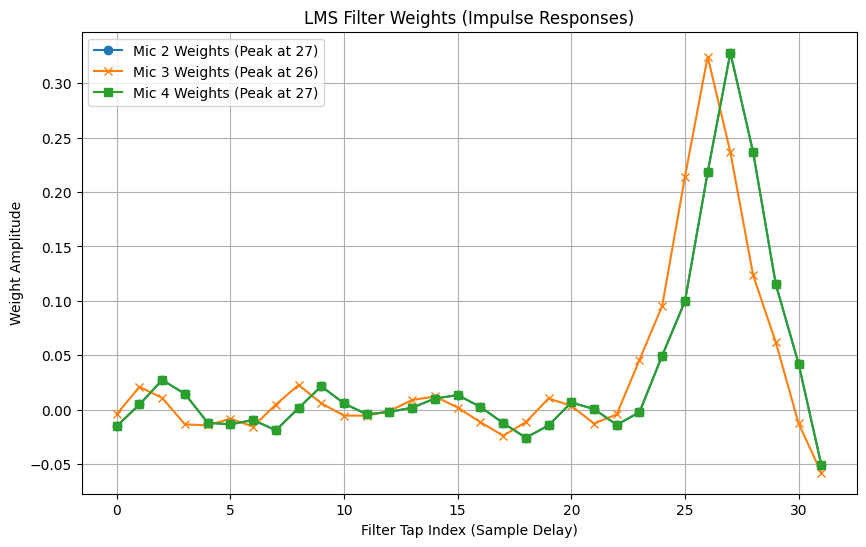

In [17]:
# --- Assuming 'final_audio_matrix' is available from the previous block ---

# 1. Setup Parameters
L = 32      # Filter length (must be larger than the expected delay)
mu = 0.1    # Step size

# Mic 1 is our ground truth desired signal d(n)
d = final_audio_matrix[0]

# 2. Run the 3 parallel filters
print("Running LMS Filters...")
w21 = run_nlms(final_audio_matrix[1], d, L, mu)
w31 = run_nlms(final_audio_matrix[2], d, L, mu)
w41 = run_nlms(final_audio_matrix[3], d, L, mu)

# 3. Extract the Time Delays (Peak Detection)
# The index of the highest weight corresponds to the sample delay
delay_21 = np.argmax(np.abs(w21))
delay_31 = np.argmax(np.abs(w31))
delay_41 = np.argmax(np.abs(w41))

print(f"\nCalculated Delays relative to Mic 1:")
print(f"Mic 2 Delay (tau_21): {delay_21} samples")
print(f"Mic 3 Delay (tau_31): {delay_31} samples")
print(f"Mic 4 Delay (tau_41): {delay_41} samples")

# 4. Visualize the Filter Weights
plt.figure(figsize=(10, 6))
plt.plot(w21, label=f'Mic 2 Weights (Peak at {delay_21})', marker='o')
plt.plot(w31, label=f'Mic 3 Weights (Peak at {delay_31})', marker='x')
plt.plot(w41, label=f'Mic 4 Weights (Peak at {delay_41})', marker='s')

plt.title('LMS Filter Weights (Impulse Responses)')
plt.xlabel('Filter Tap Index (Sample Delay)')
plt.ylabel('Weight Amplitude')
plt.legend()
plt.grid(True)
plt.show()


In [21]:
def run_lms_centered(x, d, L, mu=0.01):
    """
    Standard LMS filter with a center-tapped reference signal.
    This allows the detection of both positive and negative time delays.
    """
    N = len(x)
    w = np.zeros(L)
    
    # 1. Bulk delay the reference signal by L/2
    center_tap = L // 2
    
    # Pad the beginning with zeros to shift the signal forward in time
    # and truncate the end to keep the array the same length N
    d_delayed = np.pad(d, (center_tap, 0), mode='constant')[:N]
    
    # 2. Standard LMS Loop
    for n in range(L, N):
        # Extract the L most recent samples from the input
        x_vec = x[n : n-L : -1] 
        
        # Filter phase
        y = np.dot(w, x_vec)
        
        # Error calculation (against the delayed reference)
        e = d_delayed[n] - y
        
        # Standard LMS weight update
        w = w + mu * e * x_vec
        
    return w, center_tap


Running Centered Standard LMS Filters...

True Calculated Delays (relative to Mic 1):
Mic 2 Delay: -6 samples
Mic 3 Delay: -7 samples
Mic 4 Delay: -6 samples


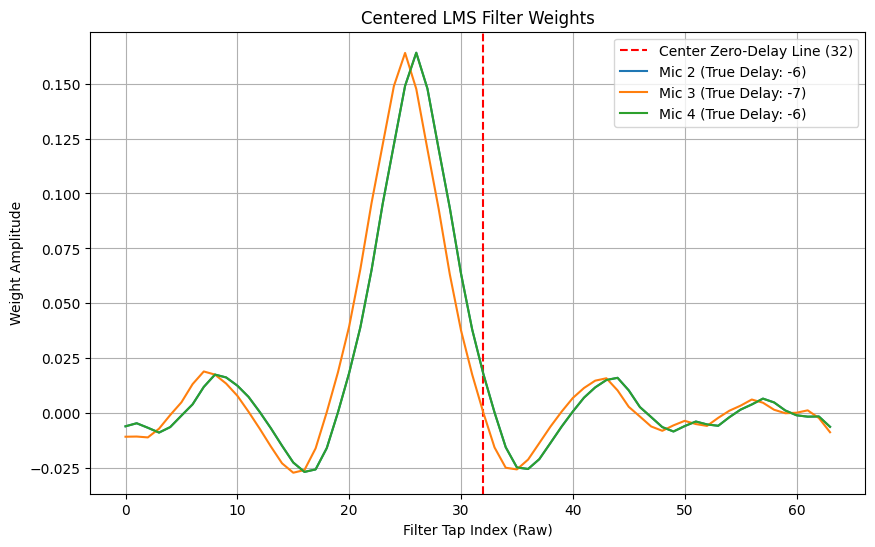

In [22]:

# --- Example Execution ---
# Assuming 'final_audio_matrix' is available from the simulation block

L = 64      # Filter length (Make sure L/2 is larger than max expected delay)
mu = 0.01   # Step size (Keep small for standard LMS to prevent overflow)

# Mic 1 is the reference
d = final_audio_matrix[0]

print("Running Centered Standard LMS Filters...")
w21, center = run_lms_centered(final_audio_matrix[1], d, L, mu)
w31, _ = run_lms_centered(final_audio_matrix[2], d, L, mu)
w41, _ = run_lms_centered(final_audio_matrix[3], d, L, mu)

# --- Extract True Time Delays ---
# 1. Find the raw peak index in the weight vector
raw_peak_21 = np.argmax(np.abs(w21))
raw_peak_31 = np.argmax(np.abs(w31))
raw_peak_41 = np.argmax(np.abs(w41))

# 2. Subtract the center tap to get the true physical delay
delay_21 = raw_peak_21 - center
delay_31 = raw_peak_31 - center
delay_41 = raw_peak_41 - center

print(f"\nTrue Calculated Delays (relative to Mic 1):")
print(f"Mic 2 Delay: {delay_21} samples")
print(f"Mic 3 Delay: {delay_31} samples")
print(f"Mic 4 Delay: {delay_41} samples")

# --- Visualization ---
plt.figure(figsize=(10, 6))

# Plot the center line for reference
plt.axvline(x=center, color='r', linestyle='--', label=f'Center Zero-Delay Line ({center})')

plt.plot(w21, label=f'Mic 2 (True Delay: {delay_21})')
plt.plot(w31, label=f'Mic 3 (True Delay: {delay_31})')
plt.plot(w41, label=f'Mic 4 (True Delay: {delay_41})')

plt.title('Centered LMS Filter Weights')
plt.xlabel('Filter Tap Index (Raw)')
plt.ylabel('Weight Amplitude')
plt.legend()
plt.grid(True)
plt.show()

In [23]:
def run_block_lms_centered(x, d, L, B, mu=0.001):
    """
    Block LMS filter with a center-tapped reference signal.
    Processes data in blocks of size B using Matrix-Vector Multiplications.
    """
    N = len(x)
    w = np.zeros(L)
    
    # 1. Bulk delay the reference signal by L/2
    center_tap = L // 2
    d_delayed = np.pad(d, (center_tap, 0), mode='constant')[:N]
    
    # Calculate how many full blocks we can process
    # We start at index L so we have enough historical samples to fill the first row
    num_blocks = (N - L) // B
    
    for k in range(num_blocks):
        # The starting index of the current block in the audio stream
        start_idx = L + k * B
        
        # 2. Build the B x L Data Matrix X(k)
        # In hardware, this is done via circular pointer reads, not physically copying.
        X_matrix = np.zeros((B, L))
        for i in range(B):
            current_n = start_idx + i
            # Extract row: L samples backwards from current_n
            X_matrix[i, :] = x[current_n : current_n - L : -1]
            
        # 3. Extract the B x 1 Desired vector for this block
        d_vec = d_delayed[start_idx : start_idx + B]
        
        # --- The SIMD Hardware Equivalence Begins Here ---
        
        # 4. Filter Phase (Matrix-Vector Multiply)
        # y = X * w  (Result is B x 1)
        y_vec = np.dot(X_matrix, w)
        
        # 5. Error Calculation
        # e = d - y  (Result is B x 1)
        e_vec = d_vec - y_vec
        
        # 6. Weight Update Phase (Matrix-Vector Multiply)
        # Gradient = X^T * e  (Result is L x 1)
        gradient = np.dot(X_matrix.T, e_vec)
        
        # Update weights
        # Note: We divide mu by B to average the gradient step, preventing overflow
        w = w + (mu / B) * gradient
        
    return w, center_tap


Running Centered Block LMS (L=64, B=128)...

True Calculated Delays (relative to Mic 1):
Mic 2 Delay: -6 samples
Mic 3 Delay: -7 samples
Mic 4 Delay: -6 samples


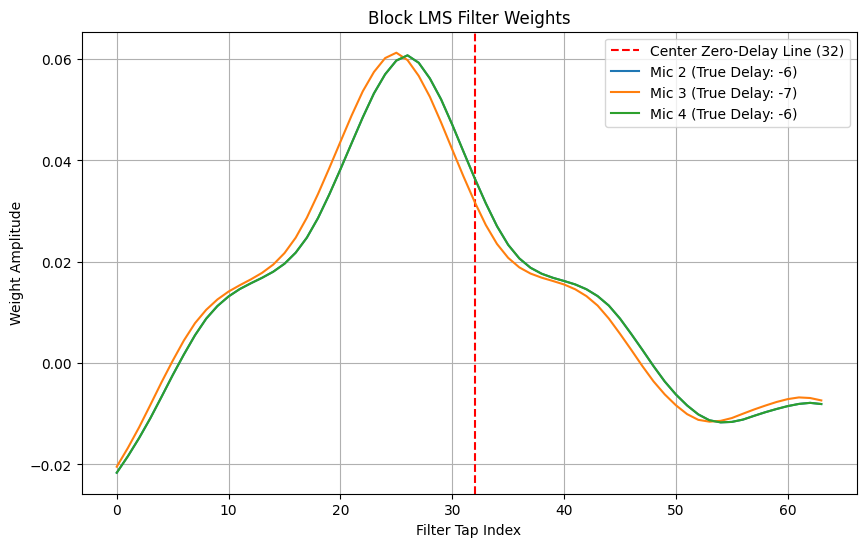

In [24]:
# --- Example Execution ---
# Assuming 'final_audio_matrix' is available from the simulation block

L = 64      # Filter length (weights vector size)
B = 128     # Block size (audio samples processed per hardware loop)
mu = 0.05   # Step size (Tuned for BLMS average)

# Mic 1 is the reference
d = final_audio_matrix[0]

print(f"Running Centered Block LMS (L={L}, B={B})...")
w21, center = run_block_lms_centered(final_audio_matrix[1], d, L, B, mu)
w31, _ = run_block_lms_centered(final_audio_matrix[2], d, L, B, mu)
w41, _ = run_block_lms_centered(final_audio_matrix[3], d, L, B, mu)

# --- Extract True Time Delays ---
delay_21 = np.argmax(np.abs(w21)) - center
delay_31 = np.argmax(np.abs(w31)) - center
delay_41 = np.argmax(np.abs(w41)) - center

print(f"\nTrue Calculated Delays (relative to Mic 1):")
print(f"Mic 2 Delay: {delay_21} samples")
print(f"Mic 3 Delay: {delay_31} samples")
print(f"Mic 4 Delay: {delay_41} samples")

# --- Visualization ---
plt.figure(figsize=(10, 6))
plt.axvline(x=center, color='r', linestyle='--', label=f'Center Zero-Delay Line ({center})')
plt.plot(w21, label=f'Mic 2 (True Delay: {delay_21})')
plt.plot(w31, label=f'Mic 3 (True Delay: {delay_31})')
plt.plot(w41, label=f'Mic 4 (True Delay: {delay_41})')
plt.title('Block LMS Filter Weights')
plt.xlabel('Filter Tap Index')
plt.ylabel('Weight Amplitude')
plt.legend()
plt.grid(True)
plt.show()